<a href="https://colab.research.google.com/github/MdAminourIslam/mnist-handwritten-digit-recognition/blob/main/MNIST_Handwritten_Digit_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [9]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


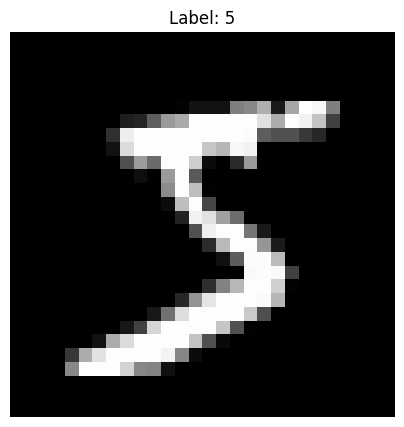

In [10]:
plt.figure(figsize=(5, 5))

plt.imshow(
    x_train[0],
    cmap="gray"
)

plt.title(f"Label: {y_train[0]}")
plt.axis("off")

plt.show()

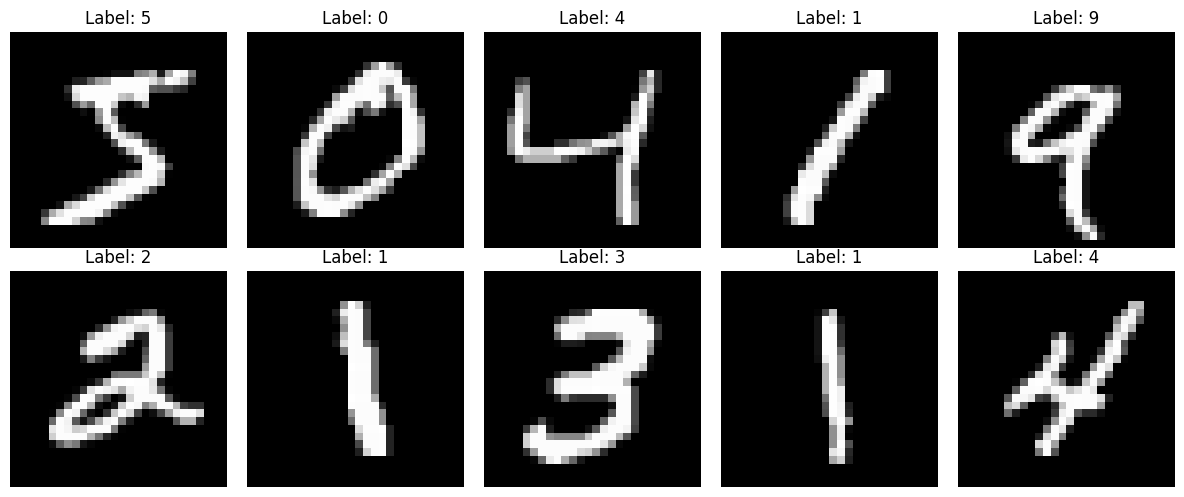

In [11]:
plt.figure(figsize=(12, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_train[i],
        cmap="gray"
    )

    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [13]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

Minimum: 0.0
Maximum: 1.0


In [14]:
print(x_train.shape)

(60000, 28, 28)


In [15]:
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [16]:
from tensorflow.keras import models, layers

In [17]:
# Build the CNN model for MNIST handwritten digit classification


from tensorflow.keras import models, layers

model = models.Sequential([

    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(
        10,
        activation="softmax"
    )
])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
# Train the CNN model using the MNIST training dataset

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9474 - loss: 0.1747 - val_accuracy: 0.9852 - val_loss: 0.0535
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9836 - loss: 0.0523 - val_accuracy: 0.9873 - val_loss: 0.0491
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9885 - loss: 0.0363 - val_accuracy: 0.9888 - val_loss: 0.0398
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9916 - loss: 0.0281 - val_accuracy: 0.9905 - val_loss: 0.0341
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9933 - loss: 0.0209 - val_accuracy: 0.9900 - val_loss: 0.0369


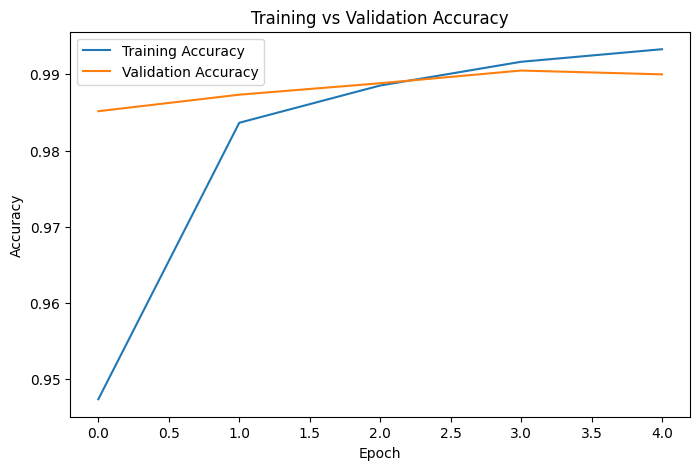

In [21]:
# Plot training and validation accuracy across epochs

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

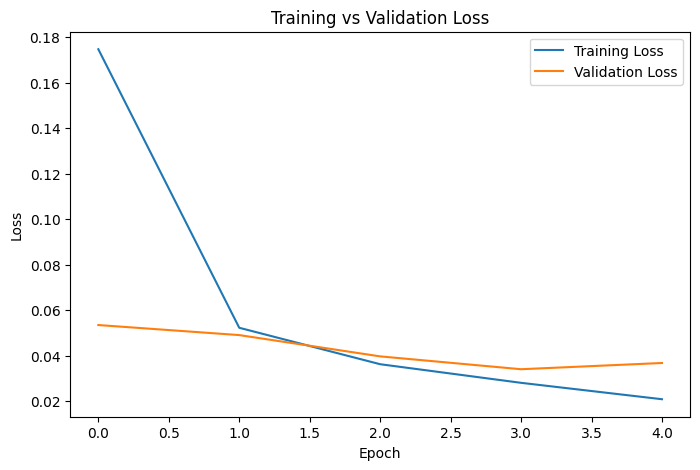

In [22]:
# Plot training and validation loss across epochs

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [23]:
# Evaluate the trained CNN model on the unseen MNIST test dataset

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9888 - loss: 0.0357
Test Loss: 0.035688530653715134
Test Accuracy: 0.9887999892234802


In [24]:
# Generate class probabilities for one test image

predictions = model.predict(
    x_test[:1]
)

print("Prediction probabilities:")
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step
Prediction probabilities:
[[9.4754338e-10 1.7046473e-08 2.6063100e-07 3.9402551e-07 1.2720303e-12
  5.0071747e-10 3.6797466e-15 9.9999893e-01 7.3246598e-10 3.5860421e-07]]


In [25]:
# Find the digit with the highest predicted probability

predicted_digit = np.argmax(
    predictions[0]
)

print("Predicted Digit:", predicted_digit)
print("Actual Digit:", y_test[0])

Predicted Digit: 7
Actual Digit: 7


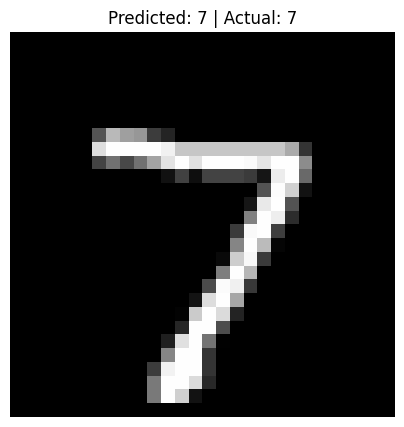

In [26]:
# Display a test image together with the predicted and actual digit

plt.figure(figsize=(5, 5))

plt.imshow(
    x_test[0].squeeze(),
    cmap="gray"
)

plt.title(
    f"Predicted: {predicted_digit} | Actual: {y_test[0]}"
)

plt.axis("off")
plt.show()

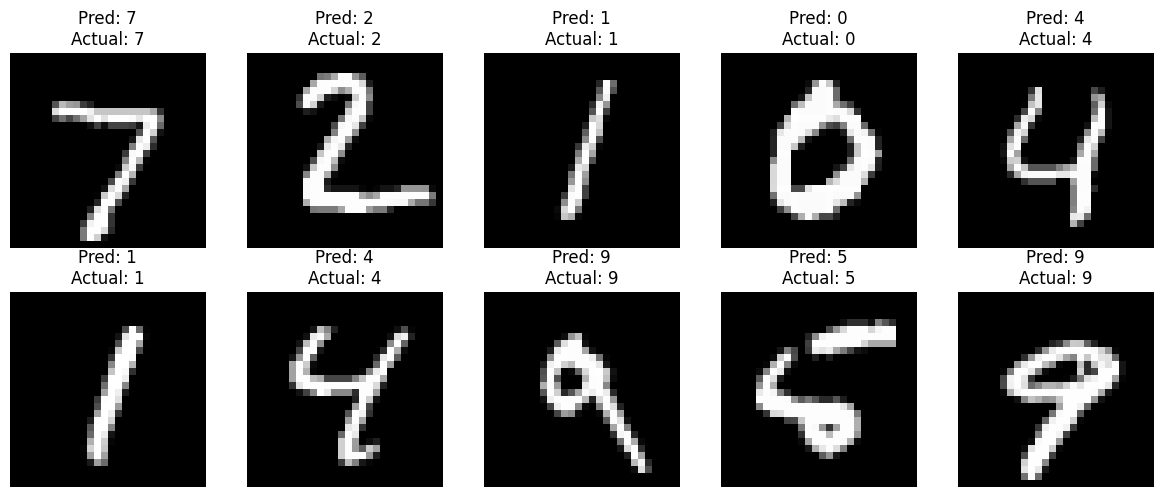

In [27]:
# Display 10 test images with their predicted and actual labels

plt.figure(figsize=(12, 5))

for i in range(10):

    prediction = np.argmax(
        model.predict(
            x_test[i:i+1],
            verbose=0
        )[0]
    )

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_test[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Pred: {prediction}\nActual: {y_test[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
# Generate predictions for all MNIST test images

y_pred_prob = model.predict(
    x_test,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

print("Prediction shape:", y_pred.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Prediction shape: (10000,)


In [29]:
# Create the confusion matrix from actual and predicted labels

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 978    0    0    0    0    0    1    1    0    0]
 [   0 1133    2    0    0    0    0    0    0    0]
 [   1    0 1029    0    0    0    0    2    0    0]
 [   0    0    3 1000    0    5    0    1    1    0]
 [   0    0    0    0  979    0    1    0    0    2]
 [   0    0    0    7    0  883    1    0    0    1]
 [   5    2    1    0    1    4  945    0    0    0]
 [   0    7   15    0    0    0    0 1001    1    4]
 [  10    0    3    1    0    1    0    1  955    3]
 [   2    3    1    1    6    6    0    1    4  985]]


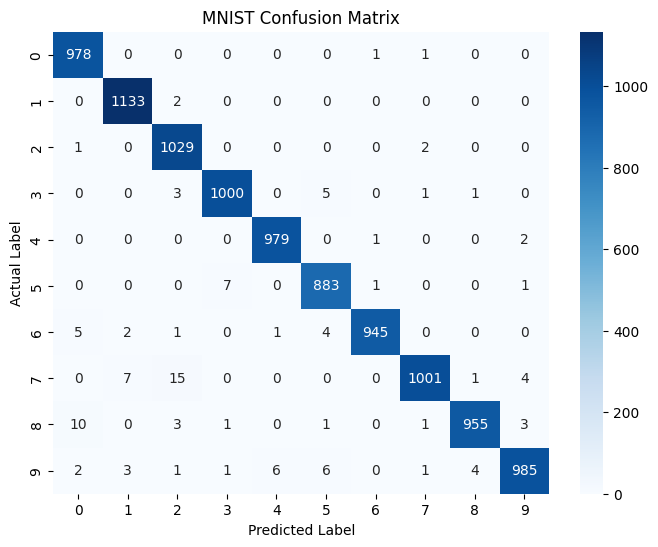

In [30]:
# Visualize the confusion matrix as a heatmap

import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("MNIST Confusion Matrix")

plt.show()

In [31]:
# Find the test images that were incorrectly classified

wrong_indices = np.where(
    y_pred != y_test
)[0]

print("Total wrong predictions:", len(wrong_indices))

Total wrong predictions: 112


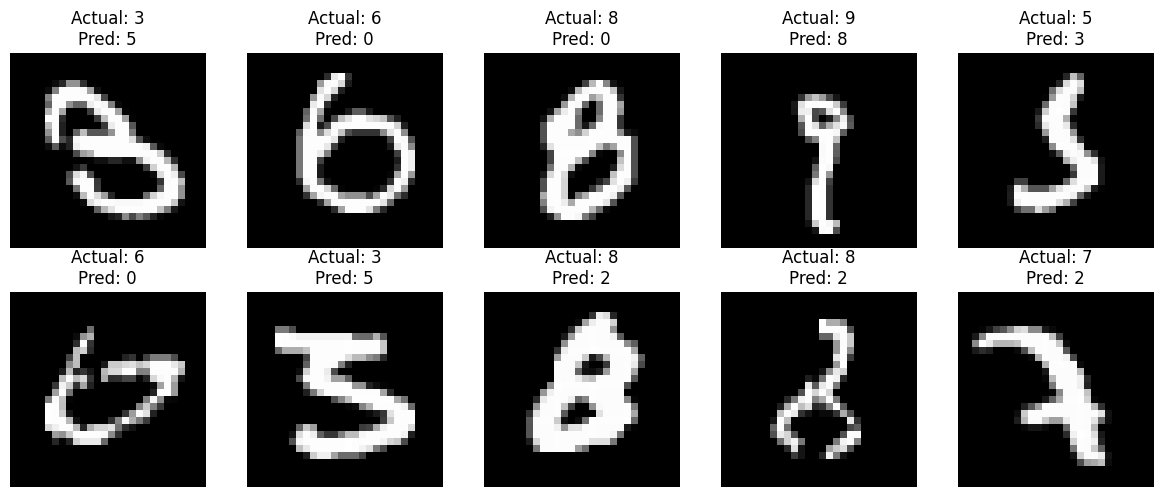

In [32]:
# Display examples of incorrectly classified MNIST images

plt.figure(figsize=(12, 5))

for i, index in enumerate(wrong_indices[:10]):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_test[index].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Actual: {y_test[index]}\n"
        f"Pred: {y_pred[index]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [47]:
 # Upload a handwritten digit image for CNN prediction

from google.colab import files

uploaded = files.upload()

Saving 8.jfif to 8.jfif


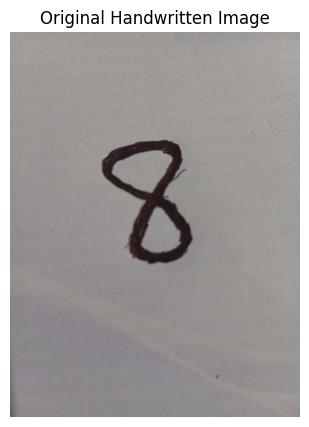

In [48]:
# Load and display the uploaded handwritten digit image

import cv2
import matplotlib.pyplot as plt

image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Handwritten Image")
plt.axis("off")
plt.show()

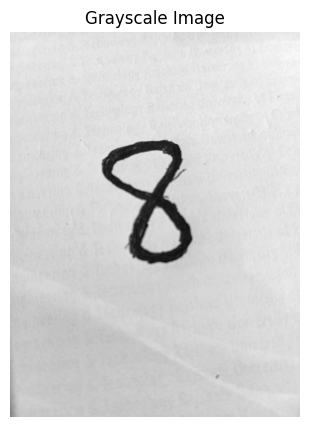

In [49]:
# Convert the handwritten image from color to grayscale

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

plt.figure(figsize=(5, 5))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

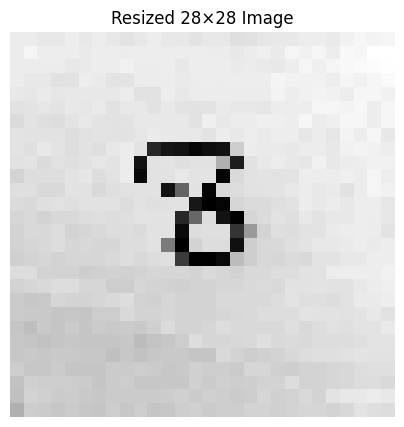

In [50]:
# Resize the handwritten digit image to the MNIST input size

resized = cv2.resize(
    gray,
    (28, 28)
)

plt.figure(figsize=(5, 5))
plt.imshow(resized, cmap="gray")
plt.title("Resized 28×28 Image")
plt.axis("off")
plt.show()

In [51]:
# Normalize pixel values to the 0–1 range like the MNIST training data

processed = resized.astype("float32") / 255.0

print("Minimum pixel value:", processed.min())
print("Maximum pixel value:", processed.max())

Minimum pixel value: 0.101960786
Maximum pixel value: 0.654902


In [52]:
# Add batch and channel dimensions to match the CNN input shape

input_image = processed.reshape(
    1,
    28,
    28,
    1
)

print("Input shape:", input_image.shape)

Input shape: (1, 28, 28, 1)


In [53]:
# Predict the handwritten digit using the trained CNN model

prediction_probabilities = model.predict(
    input_image,
    verbose=0
)

predicted_digit = np.argmax(
    prediction_probabilities[0]
)

print("Predicted Digit:", predicted_digit)

Predicted Digit: 0


In [54]:
# Display the prediction probability for every digit class

for digit, probability in enumerate(
    prediction_probabilities[0]
):
    print(
        f"Digit {digit}: {probability * 100:.2f}%"
    )

Digit 0: 30.32%
Digit 1: 1.40%
Digit 2: 9.36%
Digit 3: 0.86%
Digit 4: 15.19%
Digit 5: 7.81%
Digit 6: 11.40%
Digit 7: 2.06%
Digit 8: 18.54%
Digit 9: 3.07%


Saving 8.jfif to 8 (1).jfif


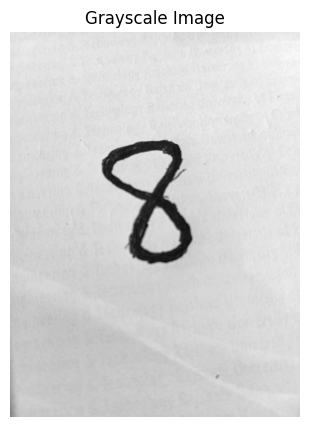

In [55]:
# Upload and load a handwritten digit image

from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5, 5))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

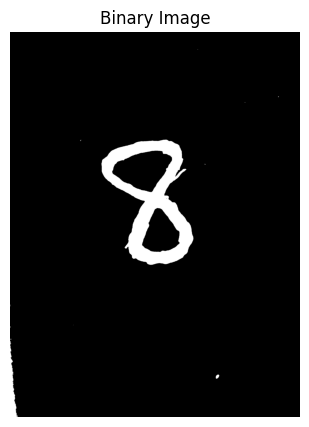

In [56]:
# Convert the grayscale image into a binary image

_, binary = cv2.threshold(
    gray,
    127,
    255,
    cv2.THRESH_BINARY_INV
)

plt.figure(figsize=(5, 5))
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()

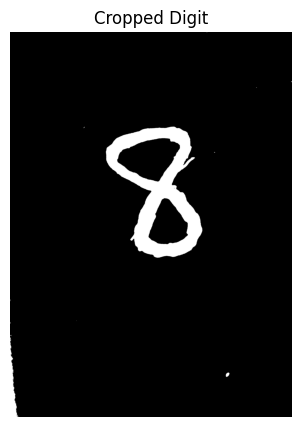

In [57]:
# Find the bounding box around the handwritten digit

coords = cv2.findNonZero(binary)

if coords is None:
    raise ValueError("No digit detected. Check your image.")

x, y, w, h = cv2.boundingRect(coords)

cropped = binary[y:y+h, x:x+w]

plt.figure(figsize=(5, 5))
plt.imshow(cropped, cmap="gray")
plt.title("Cropped Digit")
plt.axis("off")
plt.show()

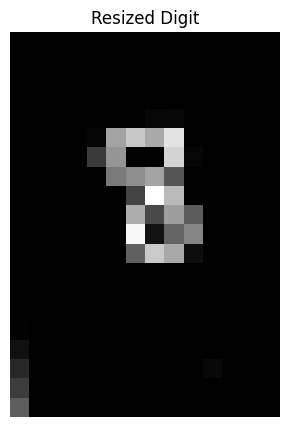

In [58]:
# Resize the cropped digit while preserving its aspect ratio

height, width = cropped.shape

scale = 20 / max(height, width)

new_width = max(1, int(width * scale))
new_height = max(1, int(height * scale))

resized_digit = cv2.resize(
    cropped,
    (new_width, new_height),
    interpolation=cv2.INTER_AREA
)

plt.figure(figsize=(5, 5))
plt.imshow(resized_digit, cmap="gray")
plt.title("Resized Digit")
plt.axis("off")
plt.show()

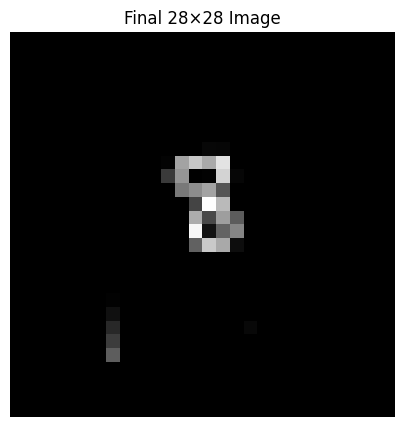

In [59]:
# Place the resized digit at the center of a 28×28 black canvas

canvas = np.zeros((28, 28), dtype=np.uint8)

x_offset = (28 - new_width) // 2
y_offset = (28 - new_height) // 2

canvas[
    y_offset:y_offset + new_height,
    x_offset:x_offset + new_width
] = resized_digit

plt.figure(figsize=(5, 5))
plt.imshow(canvas, cmap="gray")
plt.title("Final 28×28 Image")
plt.axis("off")
plt.show()

Predicted Digit: 9
Confidence: 49.58%


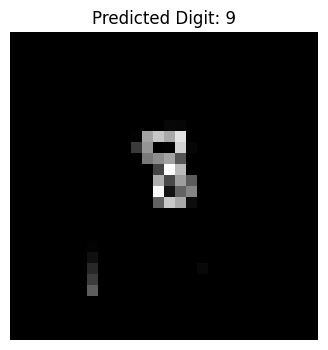

In [60]:
# Normalize the processed image and predict its digit using the CNN

input_image = canvas.astype("float32") / 255.0

input_image = input_image.reshape(1, 28, 28, 1)

prediction_probabilities = model.predict(
    input_image,
    verbose=0
)

predicted_digit = np.argmax(prediction_probabilities[0])

print("Predicted Digit:", predicted_digit)
print(
    "Confidence:",
    f"{prediction_probabilities[0][predicted_digit] * 100:.2f}%"
)

plt.figure(figsize=(4, 4))
plt.imshow(canvas, cmap="gray")
plt.title(f"Predicted Digit: {predicted_digit}")
plt.axis("off")
plt.show()